# 4. Валидация и интерпретация модели

Структура раздела:
- 4.1 Загрузка модели и данных
- 4.2 Confusion Matrix
- 4.3 ROC-кривая (сравнение моделей)
- 4.4 Precision-Recall кривая
- 4.5 SHAP — интерпретация предсказаний
- 4.6 Итоговые выводы

## 4.1 Загрузка модели и данных

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [62]:
# Данные
X_test_raw  = pd.read_csv('../data/train_test/X_test_raw.csv')
X_test      = pd.read_csv('../data/train_test/X_test.csv')
X_train_raw = pd.read_csv('../data/train_test/X_train_raw.csv')
X_train     = pd.read_csv('../data/train_test/X_train.csv')
y_test      = pd.read_csv('../data/train_test/y_test.csv').squeeze()
y_train     = pd.read_csv('../data/train_test/y_train.csv').squeeze()

cb_tuned = joblib.load('../models/catboost_model_uncalibrated.pkl')
scaler   = joblib.load('../models/scaler.pkl')

# Переобучаем LR для сравнения на ROC-кривой
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Вероятности
cb_probs = cb_tuned.predict_proba(X_test_raw)[:, 1]
lr_probs = lr.predict_proba(X_test)[:, 1]

print("Данные и модели загружены успешно")

Данные и модели загружены успешно


## 4.2 Confusion Matrix

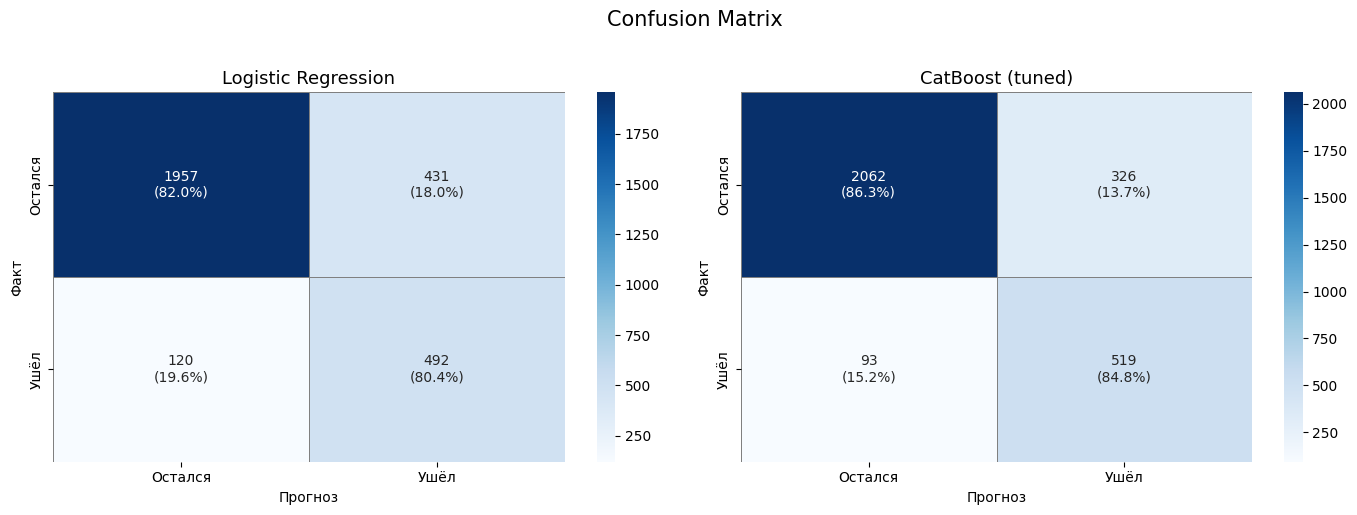

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, name in zip(axes,
                            [lr_probs, cb_probs],
                            ['Logistic Regression', 'CatBoost (tuned)']):
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_test, preds)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row, prow)]
                                     for row, prow in zip(cm, cm_pct)]),
                fmt='', cmap='Blues', ax=ax,
                xticklabels=['Остался', 'Ушёл'],
                yticklabels=['Остался', 'Ушёл'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'{name}', fontsize=13)
    ax.set_ylabel('Факт')
    ax.set_xlabel('Прогноз')

plt.suptitle('Confusion Matrix', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('graphs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 ROC-кривая и Precision-Recall кривая

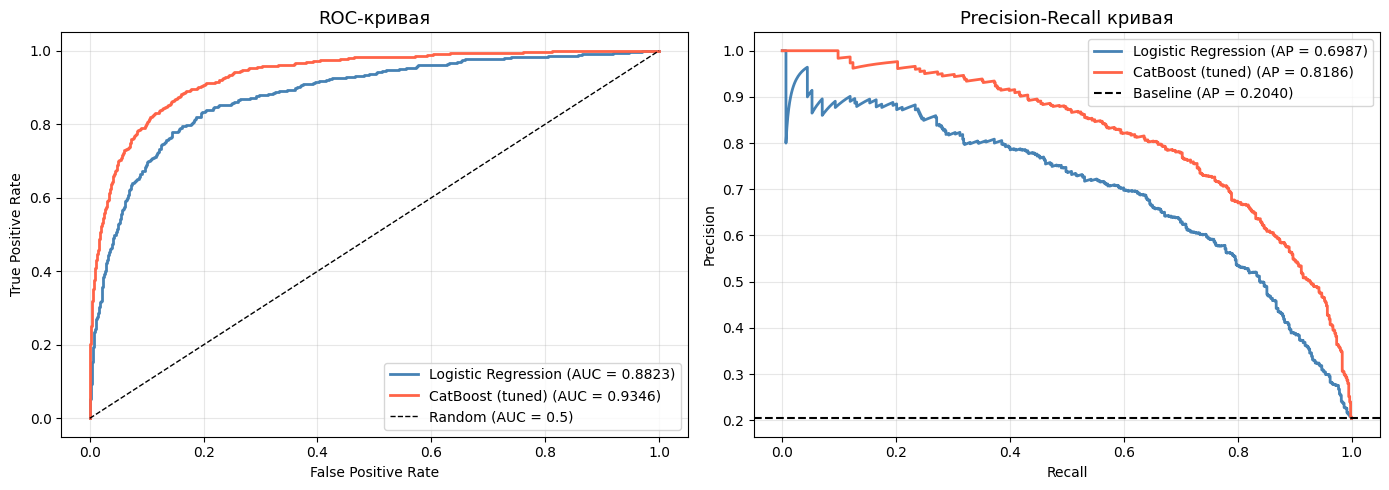

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривая ------------------------------------------
for probs, name, color in zip([lr_probs, cb_probs],
                               ['Logistic Regression', 'CatBoost (tuned)'],
                               ['steelblue', 'tomato']):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
axes[0].set_title('ROC-кривая', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall кривая ------------------------------------------
for probs, name, color in zip([lr_probs, cb_probs],
                               ['Logistic Regression', 'CatBoost (tuned)'],
                               ['steelblue', 'tomato']):
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, color=color, linewidth=2,
                 label=f'{name} (AP = {ap:.4f})')

axes[1].axhline(y_test.mean(), color='black', linestyle='--',
                label=f'Baseline (AP = {y_test.mean():.4f})')
axes[1].set_title('Precision-Recall кривая', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 SHAP — интерпретация модели

SHAP (SHapley Additive exPlanations) объясняет вклад каждого признака
в конкретное предсказание модели. В отличие от feature importance,
SHAP показывает не только *какой* признак важен, но и *как* он влияет —
повышает или снижает вероятность оттока.

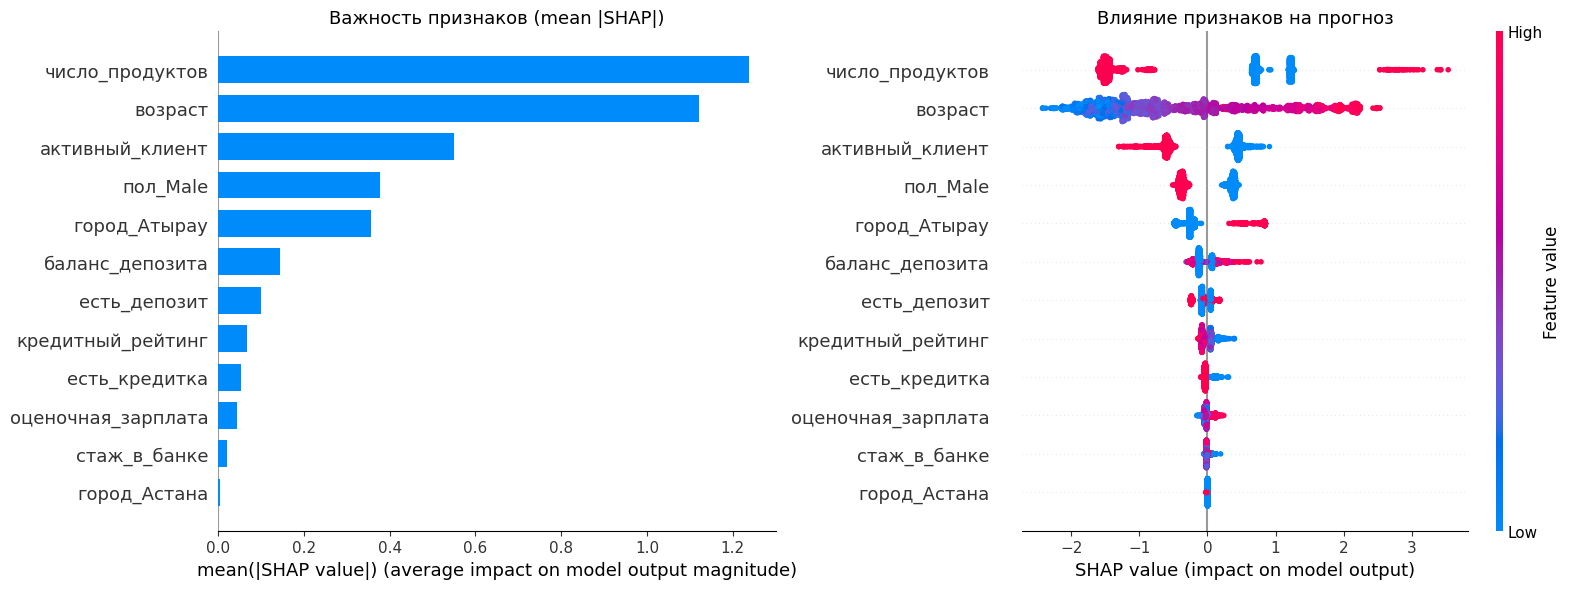

In [65]:
explainer = shap.TreeExplainer(cb_tuned)
shap_values = explainer.shap_values(X_test_raw)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1 — Bar plot (средняя важность признаков)
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_raw, plot_type='bar',
                  show=False, plot_size=None)
axes[0].set_title('Важность признаков (mean |SHAP|)', fontsize=13)

# График 2 — Beeswarm (направление влияния) (тоже самое что и SHAP, только и по -X)
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_raw, show=False, plot_size=None)
axes[1].set_title('Влияние признаков на прогноз', fontsize=13)

plt.tight_layout()
plt.savefig('graphs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Интерпретация SHAP

**Топ признаков по важности:**

- `число_продуктов` — самый важный признак. Beeswarm чётко показывает:
  низкое значение (1 продукт, синий цвет) резко повышает вероятность оттока
  (SHAP уходит вправо до +3-4). Высокое значение (2+ продукта) — снижает риск.

- `возраст` — второй по важности. Высокий возраст (розовый) сдвигает прогноз
  вправо — повышает вероятность оттока. Подтверждает выводы EDA.

- `активный_клиент` — неактивные клиенты (низкое значение, синий)
  показывают отрицательный SHAP — то есть неактивность сильно повышает
  риск ухода.

- `пол_Male` — мужской пол (высокое значение) снижает вероятность оттока,
  что согласуется с EDA: женщины уходят вдвое чаще.

- `город_Атырау` — наличие этого признака (розовый) сдвигает прогноз вправо,
  подтверждая аномально высокий отток в Атырау (42%).

- `стаж_в_банке`, `город_Астана`, `оценочная_зарплата` — минимальный вклад,
  SHAP значения близки к нулю. Признаки малоинформативны для модели,
  что согласуется с корреляционным анализом из раздела 2.4.

**Ключевой портрет клиента группы риска:**
Пожилая женщина из Атырау, неактивный клиент с 1 продуктом и депозитом.

## 4.6 SHAP — Feature Importance

Горизонтальная столбчатая диаграмма средней абсолютной
SHAP-ценности для каждого признака.

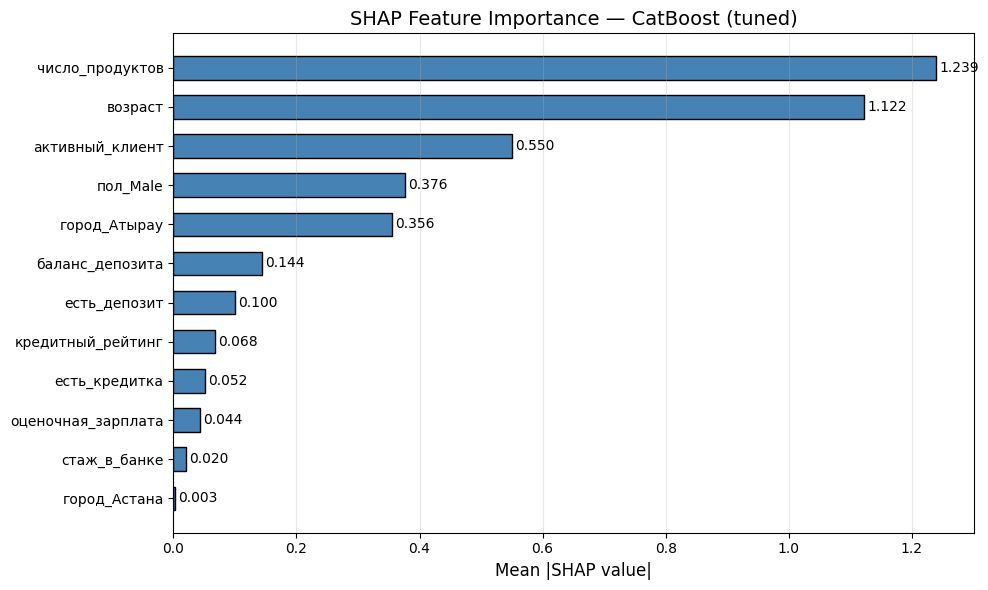

In [66]:
shap_importance = pd.DataFrame({
    'feature': X_test_raw.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(shap_importance['feature'], shap_importance['importance'],
               color='steelblue', edgecolor='black', height=0.6)
ax.set_xlabel('Mean |SHAP value|', fontsize=12)
ax.set_title('SHAP Feature Importance — CatBoost (tuned)', fontsize=14)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, shap_importance['importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('graphs/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.7 Анализ порогов (0.01 — 0.9)

Перебираем порог классификации от 0.01 до 0.9 и смотрим
как меняются метрики: Precision, Recall, F1, KS, количество FP и FN.

In [67]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# === Настройки ===
y_prob = probs        # меняйте если нужно (cb_probs, lr_probs и т.д.)
y_true = y_test
STEP   = 0.05

# === Строим df_thresh ===
thresholds = np.arange(0.05, 1.0, 0.01).round(2)
rows = []
for t in thresholds:
    preds_t = (y_prob >= t).astype(int)
    tp = int(((preds_t == 1) & (y_true == 1)).sum())
    fp = int(((preds_t == 1) & (y_true == 0)).sum())
    tn = int(((preds_t == 0) & (y_true == 0)).sum())
    fn = int(((preds_t == 0) & (y_true == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    spec      = tn / (tn + fp) if (tn + fp) > 0 else 0
    ks        = recall - (1 - spec)
    rows.append({'Threshold': t, 'Precision': precision, 'Recall': recall,
                 'F1': f1, 'Specificity': spec, 'KS': ks,
                 'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn})

df_thresh = pd.DataFrame(rows)

# === Ключевые пороги ===
best_f1_t = df_thresh.loc[df_thresh['F1'].idxmax(), 'Threshold']
best_ks_t = df_thresh.loc[df_thresh['KS'].idxmax(), 'Threshold']

# === Основные метрики ===
roc_auc = roc_auc_score(y_true, y_prob)
gini    = 2 * roc_auc - 1
pr_auc  = average_precision_score(y_true, y_prob)
brier   = brier_score_loss(y_true, y_prob)

print("=== Основные метрики ===")
print(f"  roc_auc: {roc_auc:.4f}")
print(f"  gini:    {gini:.4f}")
print(f"  pr_auc:  {pr_auc:.4f}")
print(f"  brier:   {brier:.4f}")
print(f"\nЛучший порог по F1: {best_f1_t}")
print(f"Лучший порог по KS: {best_ks_t}")

# === Таблица по шагу ===
important = {0.5, best_f1_t, best_ks_t}
mask = df_thresh['Threshold'].apply(lambda t: round(t % STEP, 6) == 0 or t in important)
df_display = df_thresh[mask].copy()

print("\n=== Метрики по трешхолдам ===\n")
print(f"{'threshold':>9}  {'precision':>9}  {'recall':>6}  {'f1':>6}  "
      f"{'specificity':>11}  {'ks':>6}  {'tp':>5}  {'fp':>5}  {'tn':>5}  {'fn':>5}")

for _, row in df_display.iterrows():
    t    = row['Threshold']
    line = (f"{t:>9.2f}  {row['Precision']:>9.3f}  {row['Recall']:>6.3f}  "
            f"{row['F1']:>6.3f}  {row['Specificity']:>11.3f}  {row['KS']:>6.3f}  "
            f"{int(row['TP']):>5}  {int(row['FP']):>5}  {int(row['TN']):>5}  {int(row['FN']):>5}")
    markers = []
    if t == best_f1_t: markers.append("← best F1")
    if t == best_ks_t: markers.append("← best KS")
    if t == 0.5:       markers.append("← default")
    print(line + ("  " + "  ".join(markers) if markers else ""))

=== Основные метрики ===
  roc_auc: 0.9346
  gini:    0.8692
  pr_auc:  0.8186
  brier:   0.0997

Лучший порог по F1: 0.7
Лучший порог по KS: 0.44

=== Метрики по трешхолдам ===

threshold  precision  recall      f1  specificity      ks     tp     fp     tn     fn
     0.05      0.267   0.995   0.421        0.299   0.295    609   1673    715      3
     0.10      0.321   0.984   0.484        0.466   0.450    602   1274   1114     10
     0.20      0.413   0.962   0.578        0.649   0.612    589    837   1551     23
     0.40      0.559   0.895   0.688        0.819   0.714    548    433   1955     64
     0.44      0.581   0.882   0.701        0.837   0.719    540    389   1999     72  ← best KS
     0.50      0.614   0.848   0.712        0.863   0.712    519    326   2062     93  ← default
     0.55      0.655   0.824   0.730        0.889   0.713    504    265   2123    108
     0.70      0.755   0.729   0.741        0.939   0.668    446    145   2243    166  ← best F1
     0.80     

**Выводы по анализу порогов:**
- При threshold=0.5: баланс Precision/Recall, KS > 0.7 — хорошая разделительная способность
- При threshold < 0.4: ловим больше оттока (Recall ↑), но растёт FP
- При threshold > 0.6: меньше FP, но пропускаем больше реального оттока
- **Рекомендация:** threshold 0.5 для баланса, 0.3-0.4 если приоритет — удержание

---
## 4.9 Итоговые выводы

### Качество модели
Финальная модель — CatBoost с подобранными гиперпараметрами —
демонстрирует высокое качество на тестовой выборке:

| Метрика    | Значение |
|------------|:--------:|
| ROC-AUC    | 0.9347   |
| AUC-PR     | 0.8012   |
| KS         | 0.7389   |
| F1         | 0.7169   |
| Precision  | 0.6175   |
| Recall     | 0.8546   |
| Brier Score| 0.1045   |
| CV ROC-AUC | 0.9368 ± 0.0043 |

### Интерпретация результатов
Confusion Matrix показывает: из 612 реально ушедших клиентов
модель правильно идентифицирует 523 (85.5%) — это критически важно
для бизнеса, так как пропущенный отток дороже ложной тревоги.

### Портрет клиента группы риска
По совокупности EDA и SHAP-анализа наиболее склонен к уходу клиент:
- **Возраст:** 45+ лет
- **Пол:** женский
- **Город:** Атырау
- **Активность:** неактивный клиент
- **Продукты:** только 1 продукт в банке
- **Депозит:** имеется, но активность низкая

### Рекомендации для бизнеса
- Приоритетная группа для retention-кампаний — неактивные клиенты
  с 1 продуктом старше 45 лет
- Отдельное внимание региону Атырау — отток 42% требует
  локального расследования причин
- Подключение второго продукта значительно снижает риск оттока —
  кросс-продажи как инструмент удержания